In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from nltk.sentiment import SentimentIntensityAnalyzer

In [ ]:
df=pd.read_csv('cleaned_final_10k_dataset.csv')
df

,headline,date,section,type,source,text_snippet,full_text,compound_score,pos_score,neg_score,is_after_election
0,Harris attacks Trump over Roe v Wade at first ...,2024-01-23,US news,Politics,The Guardian,Vice-president appeared Tuesday in Virginia wi...,Joe Biden and Kamala Harris kicked off their f...,-0.4404,0.000,0.209,False
1,Biden re-election campaign to put emphasis on ...,2024-01-03,US news,Politics,The Guardian,Biden-Harris camp announces campaign plan that...,"Good morning. Ailing in opinion polls, Joe Bid...",-0.3818,0.000,0.191,False
2,Biden attacks Trump as grave threat to democra...,2024-01-05,US news,Politics,The Guardian,"On eve of January 6 anniversary, US president ...",A day before the third anniversary of the Janu...,-0.8360,0.000,0.497,False
3,Sherrilyn Ifill on a Trump win: ‘We will cease...,2024-01-07,US news,Politics,The Guardian,The longtime civil rights lawyer on the 14th a...,The timing is right for a 14th amendment renai...,0.5859,0.275,0.000,False
4,Icy battle for democracy in Iowa with Trump ex...,2024-01-15,US news,Politics,The Guardian,The first stage of the 2024 election takes pla...,A cold coming we had of it. Icy winds blow acr...,0.2960,0.196,0.134,False
...,...,...,...,...,...,...,...,...,...,...,...
10842,Europe’s Growing Fear: How Trump Might Use U.S...,2025-06-20,Technology,Conflict,New York Times,"To comply with a Trump executive order, Micros...","To comply with a Trump executive order, Micros...",-0.1779,0.223,0.204,True
10843,Israel Attacked Iran’s State TV,2025-06-16,Briefing,Conflict,New York Times,"Also, the suspect in the Minnesota killings co...","Also, the suspect in the Minnesota killings co...",-0.4588,0.000,0.429,True
10844,"Starmer Picks Up Trump’s Papers, and 2 Small P...",2025-06-17,World,Conflict,New York Times,The British prime minister scrambled at Presid...,The British prime minister scrambled at Presid...,0.5719,0.316,0.000,True
10845,A Primary and a Heat Wave,2025-06-25,Briefing,Conflict,New York Times,We’re covering the upset in New York City and ...,We’re covering the upset in New York City and ...,0.0000,0.000,0.000,True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Check for missing values in the DataFrame.
# 1.isnull(): Returns a DataFrame of True/False values (True where data is missing/NaN).
# 2.sum(): Counts the 'True' values for each column (since True = 1 and False = 0).

df.isnull().sum()

,0
headline,0
date,0
section,0
type,0
source,0
text_snippet,0
full_text,0
compound_score,0
pos_score,0
neg_score,0


In [ ]:
# Calculate the total number of rows in the DataFrame 'df'.
# We store this in 'org_len' (Original Length) to preserve the initial count
# before we perform any filtering or cleaning steps.
org_len = len(df)

# Display the count.
org_len

10847

In [ ]:
# Check for duplicate rows in the DataFrame.
# .duplicated(): Scans the data and returns True for any row that is identical to a previous one.
# .sum(): Counts the total number of 'True' values to give you the exact number of duplicate rows.

df.duplicated().sum()

np.int64(0)

In [ ]:
# Remove rows where critical text data is missing.
# subset=['text_snippet', 'full_text']: We only check these specific columns.
# If a row has a NaN in either of these, it gets deleted.
# inplace=True: Applies the change directly to 'df' (does not create a new variable).

df.dropna(subset=['text_snippet','full_text'],inplace=True)

In [ ]:
# rechecks if there is any nulls again , and sums it if there is nulls left
df.isnull().sum()

,0
headline,0
date,0
section,0
type,0
source,0
text_snippet,0
full_text,0
compound_score,0
pos_score,0
neg_score,0


In [ ]:
# Calculate the length of the DataFrame after dropping missing values.
# We store this in 'after_drop' to compare it against 'org_len' later.
after_drop = len(df)

# Display the new count.
after_drop

10847

In [ ]:
df

,headline,date,section,type,source,text_snippet,full_text,compound_score,pos_score,neg_score,is_after_election
0,Harris attacks Trump over Roe v Wade at first ...,2024-01-23,US news,Politics,The Guardian,Vice-president appeared Tuesday in Virginia wi...,Joe Biden and Kamala Harris kicked off their f...,-0.4404,0.000,0.209,False
1,Biden re-election campaign to put emphasis on ...,2024-01-03,US news,Politics,The Guardian,Biden-Harris camp announces campaign plan that...,"Good morning. Ailing in opinion polls, Joe Bid...",-0.3818,0.000,0.191,False
2,Biden attacks Trump as grave threat to democra...,2024-01-05,US news,Politics,The Guardian,"On eve of January 6 anniversary, US president ...",A day before the third anniversary of the Janu...,-0.8360,0.000,0.497,False
3,Sherrilyn Ifill on a Trump win: ‘We will cease...,2024-01-07,US news,Politics,The Guardian,The longtime civil rights lawyer on the 14th a...,The timing is right for a 14th amendment renai...,0.5859,0.275,0.000,False
4,Icy battle for democracy in Iowa with Trump ex...,2024-01-15,US news,Politics,The Guardian,The first stage of the 2024 election takes pla...,A cold coming we had of it. Icy winds blow acr...,0.2960,0.196,0.134,False
...,...,...,...,...,...,...,...,...,...,...,...
10842,Europe’s Growing Fear: How Trump Might Use U.S...,2025-06-20,Technology,Conflict,New York Times,"To comply with a Trump executive order, Micros...","To comply with a Trump executive order, Micros...",-0.1779,0.223,0.204,True
10843,Israel Attacked Iran’s State TV,2025-06-16,Briefing,Conflict,New York Times,"Also, the suspect in the Minnesota killings co...","Also, the suspect in the Minnesota killings co...",-0.4588,0.000,0.429,True
10844,"Starmer Picks Up Trump’s Papers, and 2 Small P...",2025-06-17,World,Conflict,New York Times,The British prime minister scrambled at Presid...,The British prime minister scrambled at Presid...,0.5719,0.316,0.000,True
10845,A Primary and a Heat Wave,2025-06-25,Briefing,Conflict,New York Times,We’re covering the upset in New York City and ...,We’re covering the upset in New York City and ...,0.0000,0.000,0.000,True


In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download the VADER lexicon (dictionary).
# VADER (Valence Aware Dictionary and sEntiment Reasoner) relies on a pre-built list
# of words that have been rated as positive or negative. We must download this first.
nltk.download('vader_lexicon')

# Initialize the Sentiment Analyzer.
# We create an instance 'sia' which we will use later to score our text.
# It is specifically tuned for social media and news text (handles emojis, caps, slang).
sia = SentimentIntensityAnalyzer()


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
def vader_sentiment(text):
    """
    Analyzes the sentiment of a given text string using VADER.

    Args:
        text (str): The text content to analyze.

    Returns:
        pd.Series: A series containing three float scores:
                   [0] Compound Score (Overall sentiment: -1 to +1)
                   [1] Positive Score (0 to 1)
                   [2] Negative Score (0 to 1)
    """
    # Safety Check: If the text is missing (NaN), return neutral scores (0s)
    # This prevents the function from crashing on empty rows.
    if pd.isna(text):
        return pd.Series([0, 0, 0])

    # Calculate sentiment scores using the initialized analyzer 'sia'.
    # This returns a dictionary like {'neg': 0.0, 'neu': 0.5, 'pos': 0.5, 'compound': 0.4}
    scores = sia.polarity_scores(text)

    # Return the specific scores we care about as a Pandas Series.
    # We ignore 'neu' (neutral) here to focus on the polarity.
    return pd.Series([
        scores['compound'], # The normalized, weighted composite score
        scores['pos'],      # The ratio of text that is positive
        scores['neg']       # The ratio of text that is negative
    ])


In [ ]:
# Apply the 'vader_sentiment' function to every row in the 'headline' column.
# 1.apply(vader_sentiment): Passes the text of each headline into our function.
# 2.The function returns a Series of 3 values (compound, pos, neg) for each row.
# 3.We assign these results directly to three new columns in 'df'.
df[['compound_score', 'pos_score', 'neg_score']] = df['headline'].apply(vader_sentiment)


In [ ]:
df

,headline,date,section,type,source,text_snippet,full_text,compound_score,pos_score,neg_score,is_after_election
0,Harris attacks Trump over Roe v Wade at first ...,2024-01-23,US news,Politics,The Guardian,Vice-president appeared Tuesday in Virginia wi...,Joe Biden and Kamala Harris kicked off their f...,-0.4404,0.000,0.209,False
1,Biden re-election campaign to put emphasis on ...,2024-01-03,US news,Politics,The Guardian,Biden-Harris camp announces campaign plan that...,"Good morning. Ailing in opinion polls, Joe Bid...",-0.3818,0.000,0.191,False
2,Biden attacks Trump as grave threat to democra...,2024-01-05,US news,Politics,The Guardian,"On eve of January 6 anniversary, US president ...",A day before the third anniversary of the Janu...,-0.8360,0.000,0.497,False
3,Sherrilyn Ifill on a Trump win: ‘We will cease...,2024-01-07,US news,Politics,The Guardian,The longtime civil rights lawyer on the 14th a...,The timing is right for a 14th amendment renai...,0.5859,0.275,0.000,False
4,Icy battle for democracy in Iowa with Trump ex...,2024-01-15,US news,Politics,The Guardian,The first stage of the 2024 election takes pla...,A cold coming we had of it. Icy winds blow acr...,0.2960,0.196,0.134,False
...,...,...,...,...,...,...,...,...,...,...,...
10842,Europe’s Growing Fear: How Trump Might Use U.S...,2025-06-20,Technology,Conflict,New York Times,"To comply with a Trump executive order, Micros...","To comply with a Trump executive order, Micros...",-0.1779,0.223,0.204,True
10843,Israel Attacked Iran’s State TV,2025-06-16,Briefing,Conflict,New York Times,"Also, the suspect in the Minnesota killings co...","Also, the suspect in the Minnesota killings co...",-0.4588,0.000,0.429,True
10844,"Starmer Picks Up Trump’s Papers, and 2 Small P...",2025-06-17,World,Conflict,New York Times,The British prime minister scrambled at Presid...,The British prime minister scrambled at Presid...,0.5719,0.316,0.000,True
10845,A Primary and a Heat Wave,2025-06-25,Briefing,Conflict,New York Times,We’re covering the upset in New York City and ...,We’re covering the upset in New York City and ...,0.0000,0.000,0.000,True


In [ ]:
# to check if there is any nulls again , after applying vader_sentiment function

df.isnull().sum()

,0
headline,0
date,0
section,0
type,0
source,0
text_snippet,0
full_text,0
compound_score,0
pos_score,0
neg_score,0


In [ ]:
# Count the frequency of unique combinations of sentiment scores.

# 2. value_counts(): Counts how many times each unique combination of (pos, neg, compound) appears.
# 3. reset_index(name='count'): Converts the result back into a standard DataFrame
#    and names the frequency column 'count' for readability.

df[['pos_score', 'neg_score', 'compound_score']].value_counts().reset_index(name='count')

,pos_score,neg_score,compound_score,count
0,0.000,0.000,0.0000,3376
1,0.000,0.302,-0.5994,96
2,0.000,0.262,-0.5994,56
3,0.000,0.245,-0.5994,49
4,0.000,0.281,-0.5994,48
...,...,...,...,...
3630,0.554,0.000,0.7351,1
3631,0.556,0.108,0.9231,1
3632,0.565,0.000,0.3818,1
3633,0.565,0.000,0.8442,1


In [ ]:
# Define the key election date for our analysis.
# pd.to_datetime(): Converts the string '2024-11-05' into a proper Timestamp object.
# This allows us to mathematically compare other dates to it (e.g., check if a date is > or < this date).

election_date = pd.to_datetime('2024-11-05')

In [ ]:
# Convert the 'date' column to datetime objects and remove timezone info.

# 1. pd.to_datetime(..., errors='coerce'):
#    - Tries to convert the text dates into actual Timestamp objects.
#    - errors='coerce': If a date is malformed or invalid, it turns it into NaT (Not a Time) instead of crashing the code.
# 2. .dt.tz_localize(None):
# Accesses the datetime properties (.dt).
# Removes timezone information (None). This makes the dates "timezone-naive".
# This is CRITICAL because you cannot compare a timezone-aware date (from the API) to a timezone-naive date (like your 'election_date' variable).
df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.tz_localize(None)

# Display the DataFrame to verify the change.
df

,headline,date,section,type,source,text_snippet,full_text,compound_score,pos_score,neg_score,is_after_election
0,Harris attacks Trump over Roe v Wade at first ...,2024-01-23,US news,Politics,The Guardian,Vice-president appeared Tuesday in Virginia wi...,Joe Biden and Kamala Harris kicked off their f...,-0.4404,0.000,0.209,False
1,Biden re-election campaign to put emphasis on ...,2024-01-03,US news,Politics,The Guardian,Biden-Harris camp announces campaign plan that...,"Good morning. Ailing in opinion polls, Joe Bid...",-0.3818,0.000,0.191,False
2,Biden attacks Trump as grave threat to democra...,2024-01-05,US news,Politics,The Guardian,"On eve of January 6 anniversary, US president ...",A day before the third anniversary of the Janu...,-0.8360,0.000,0.497,False
3,Sherrilyn Ifill on a Trump win: ‘We will cease...,2024-01-07,US news,Politics,The Guardian,The longtime civil rights lawyer on the 14th a...,The timing is right for a 14th amendment renai...,0.5859,0.275,0.000,False
4,Icy battle for democracy in Iowa with Trump ex...,2024-01-15,US news,Politics,The Guardian,The first stage of the 2024 election takes pla...,A cold coming we had of it. Icy winds blow acr...,0.2960,0.196,0.134,False
...,...,...,...,...,...,...,...,...,...,...,...
10842,Europe’s Growing Fear: How Trump Might Use U.S...,2025-06-20,Technology,Conflict,New York Times,"To comply with a Trump executive order, Micros...","To comply with a Trump executive order, Micros...",-0.1779,0.223,0.204,True
10843,Israel Attacked Iran’s State TV,2025-06-16,Briefing,Conflict,New York Times,"Also, the suspect in the Minnesota killings co...","Also, the suspect in the Minnesota killings co...",-0.4588,0.000,0.429,True
10844,"Starmer Picks Up Trump’s Papers, and 2 Small P...",2025-06-17,World,Conflict,New York Times,The British prime minister scrambled at Presid...,The British prime minister scrambled at Presid...,0.5719,0.316,0.000,True
10845,A Primary and a Heat Wave,2025-06-25,Briefing,Conflict,New York Times,We’re covering the upset in New York City and ...,We’re covering the upset in New York City and ...,0.0000,0.000,0.000,True


In [ ]:
# Create a new boolean column to split data into "Pre-Election" and "Post-Election".
# 1. df['date'] > election_date:
# Compares every row's date against our 'election_date' variable (Nov 5, 2024).
# Returns True if the article was published AFTER the election.
# Returns False if the article was published ON or BEFORE the election.
# 2. We store this result in 'is_after_election' to easily filter the data later.
df['is_after_election'] = df['date'] > election_date

df

,headline,date,section,type,source,text_snippet,full_text,compound_score,pos_score,neg_score,is_after_election
0,Harris attacks Trump over Roe v Wade at first ...,2024-01-23,US news,Politics,The Guardian,Vice-president appeared Tuesday in Virginia wi...,Joe Biden and Kamala Harris kicked off their f...,-0.4404,0.000,0.209,False
1,Biden re-election campaign to put emphasis on ...,2024-01-03,US news,Politics,The Guardian,Biden-Harris camp announces campaign plan that...,"Good morning. Ailing in opinion polls, Joe Bid...",-0.3818,0.000,0.191,False
2,Biden attacks Trump as grave threat to democra...,2024-01-05,US news,Politics,The Guardian,"On eve of January 6 anniversary, US president ...",A day before the third anniversary of the Janu...,-0.8360,0.000,0.497,False
3,Sherrilyn Ifill on a Trump win: ‘We will cease...,2024-01-07,US news,Politics,The Guardian,The longtime civil rights lawyer on the 14th a...,The timing is right for a 14th amendment renai...,0.5859,0.275,0.000,False
4,Icy battle for democracy in Iowa with Trump ex...,2024-01-15,US news,Politics,The Guardian,The first stage of the 2024 election takes pla...,A cold coming we had of it. Icy winds blow acr...,0.2960,0.196,0.134,False
...,...,...,...,...,...,...,...,...,...,...,...
10842,Europe’s Growing Fear: How Trump Might Use U.S...,2025-06-20,Technology,Conflict,New York Times,"To comply with a Trump executive order, Micros...","To comply with a Trump executive order, Micros...",-0.1779,0.223,0.204,True
10843,Israel Attacked Iran’s State TV,2025-06-16,Briefing,Conflict,New York Times,"Also, the suspect in the Minnesota killings co...","Also, the suspect in the Minnesota killings co...",-0.4588,0.000,0.429,True
10844,"Starmer Picks Up Trump’s Papers, and 2 Small P...",2025-06-17,World,Conflict,New York Times,The British prime minister scrambled at Presid...,The British prime minister scrambled at Presid...,0.5719,0.316,0.000,True
10845,A Primary and a Heat Wave,2025-06-25,Briefing,Conflict,New York Times,We’re covering the upset in New York City and ...,We’re covering the upset in New York City and ...,0.0000,0.000,0.000,True


In [ ]:
df.isnull().sum() # to recheck any if there is nulls again after the cleaning

,0
headline,0
date,0
section,0
type,0
source,0
text_snippet,0
full_text,0
compound_score,0
pos_score,0
neg_score,0


In [ ]:
len(df) # to check the total of the rows after cleaning

10847

In [ ]:
# Save the cleaned and processed DataFrame to a CSV file.
#'cleaned_final_10k_dataset.csv': The name of the output file.
# index=False: EXTREMELY IMPORTANT.
# By default, pandas writes the row numbers (0, 1, 2...) as the first column.
# Setting this to False prevents that

df.to_csv('cleaned_final_10k_dataset.csv', index=False)

In [ ]:
# Select only the columns that contain numeric data.
# 1.select_dtypes(include='number'):
# Scans the DataFrame 'df' and keeps only columns with numeric data types
# 2.columns:
# Extracts just the names of these columns (the headers) rather than the full data.
num_cols = df.select_dtypes(include='number').columns

# Display the list of numeric column names.
num_cols


Index(['compound_score', 'pos_score', 'neg_score'], dtype='object')

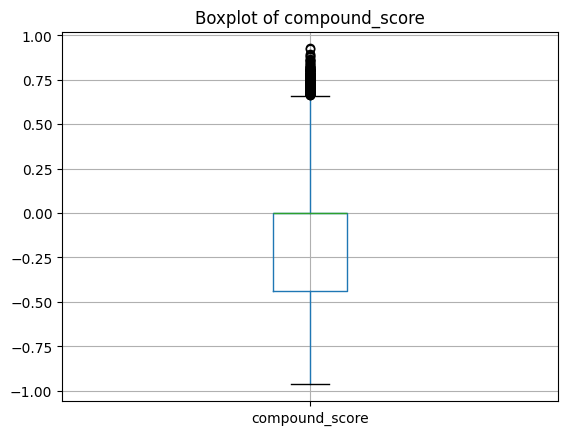

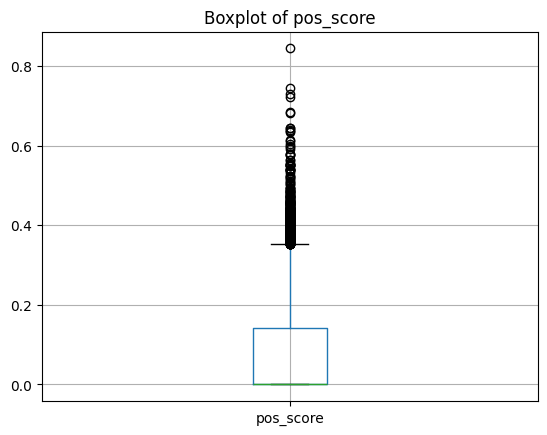

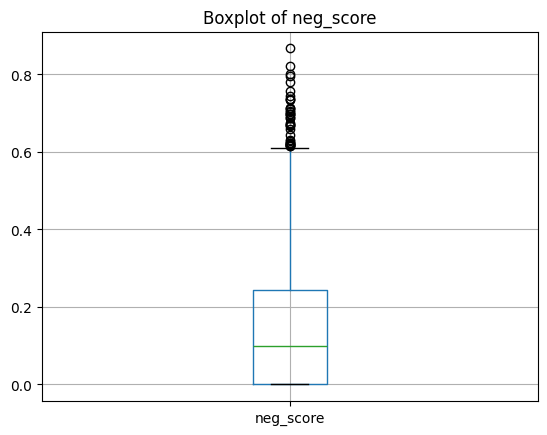

In [ ]:
# Loop through every numeric column identified in 'num_cols'.
for col in num_cols:
    # Create a new figure for each column.
    # If we don't do this, Python might try to pile all the boxplots onto a single graph.
    plt.figure()

    # Generate the boxplot for the current column.
    # A boxplot visually shows:
    # - The Median (green line usually)
    # - The Interquartile Range (the box, middle 50% of data)
    # - The Whiskers (range of typical data)
    # - The Dots (Outliers that fall far outside the normal range)
    df.boxplot(column=col)

    # Set a dynamic title so we know which variable we are looking at.
    plt.title(f'Boxplot of {col}')
    plt.show()